In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb as ddb
import numpy as np
from scipy.ndimage import histogram

ActualForecast = pd.read_csv('ActualForecastData.csv', parse_dates=['date_he'])

print(ActualForecast.info())
print(ActualForecast.head())
print(ActualForecast.tail())

<class 'pandas.DataFrame'>
RangeIndex: 30116 entries, 0 to 30115
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date_he         30116 non-null  datetime64[us]
 1   forecast_price  30116 non-null  float64       
 2   actual_price    30116 non-null  float64       
 3   forecast_ail    30116 non-null  int64         
 4   actual_ail      30116 non-null  int64         
 5   ail_diff        30116 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(3)
memory usage: 1.4 MB
None
              date_he  forecast_price  actual_price  forecast_ail  actual_ail  \
0 2023-01-01 01:00:00           88.39         80.55          9832        9824   
1 2023-01-01 02:00:00          102.36         80.84          9723        9712   
2 2023-01-01 03:00:00           80.82         80.63          9634        9623   
3 2023-01-01 04:00:00           80.61         79.76          9578        9578   
4 2023-0

#### Average demand by hour throughout the week

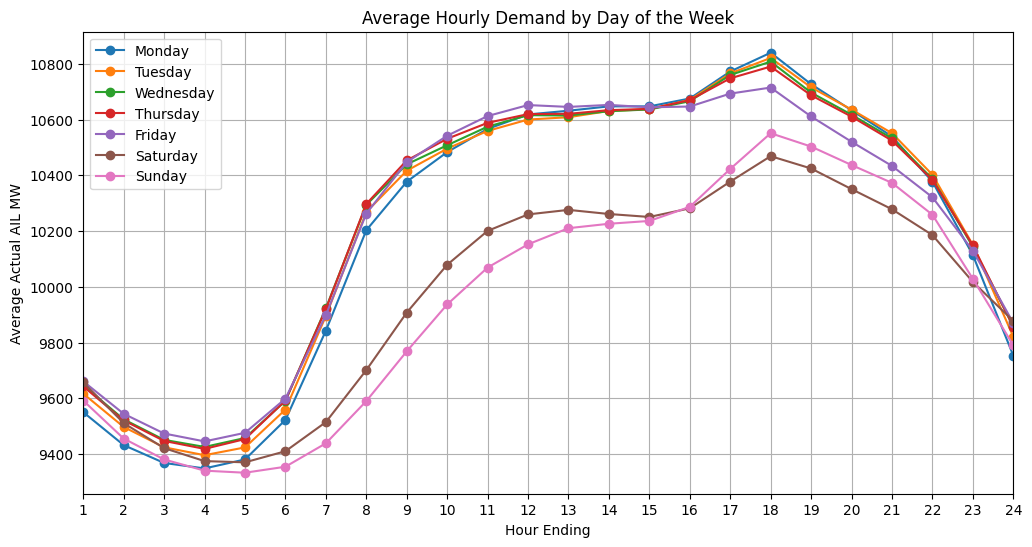

In [102]:
day_map = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}
hourly_demand = ddb.sql('''
    select
        case when hour(date_he) = 0 then 24
            else hour(date_he)
            end as hour,
        dayofweek(date_he) as day_of_week,
        avg(actual_ail) as avg_ail
    from ActualForecast
    group by hour, day_of_week
    order by hour, day_of_week
''').df()
hourly_demand = hourly_demand.pivot(index='hour', columns='day_of_week', values='avg_ail')
hourly_demand = hourly_demand.rename(columns=day_map)
hourly_demand = hourly_demand[['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']]

#################### PLOT ##############################
hourly_demand.plot(figsize=(12, 6), marker='o')
plt.xlim(1, 24)
plt.xticks(range(1, 25))
plt.title('Average Hourly Demand by Day of the Week')
plt.ylabel('Average Actual AIL MW')
plt.xlabel('Hour Ending')
plt.grid(True)
plt.legend(loc = 'upper left')

As a utility, electricity demand follows predictable patterns that smooth over time. Hourly demand shows a persistent structure: a morning spike from hours 6 to 8, a steady climb to peak demand from hours 16 to 18, then a gradual decline into a trough in the early morning hours.

Weekday volumes are closely aligned, while weekends show a significant drop in demand — though the underlying shape remains consistent.

Residential and commercial consumption drive these observed patterns. However, Alberta's heavy reliance on oil and gas introduces a substantial baseload component, as oil sands extraction requires continuous electricity regardless of time of day.

#### Average hourly demand throughout the year

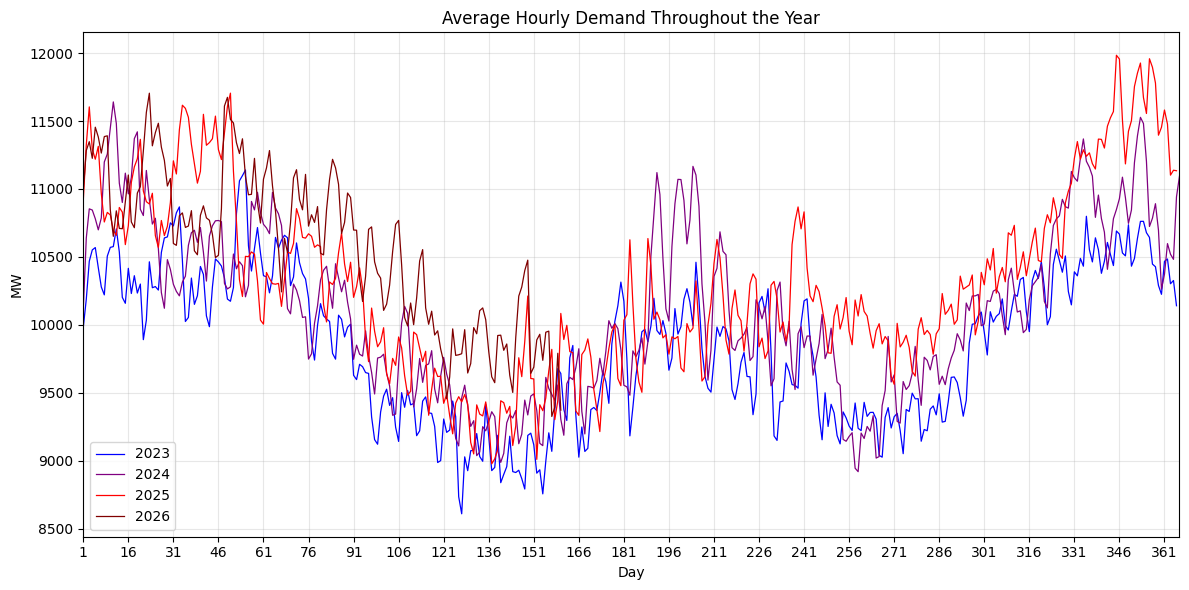

In [103]:
avg_hourly_demand = ddb.sql('''
    select
        year(date_he) as year,
        dayofyear(date_he) as doy,
        avg(actual_ail) as avg_ail
    from ActualForecast
    group by doy, year
    order by doy, year
    ''').df()

avg_hourly_demand = avg_hourly_demand.pivot(index='doy', columns='year', values='avg_ail')

fig, ax = plt.subplots(figsize=(12, 6))
avg_hourly_demand.plot(ax=ax, alpha=1, color=['blue', 'purple', 'red', 'maroon'], linewidth=0.9)
ax.set_xlabel('Day')
ax.set_ylabel('MW')
ax.set_title('Average Hourly Demand Throughout the Year')
ax.set_xlim(1, 366)
ax.set_xticks(range(1, 367, 15))
ax.legend(title=None, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Monthly demand patterns are consistent across the years. Weather conditions corresponds to heating and cooling needs as demand peaks during winter, Dec to Feb, and summer, July and August. Demand declines during milder seasons, usually reaching its lowest in May or September.

#### Hourly price-demand trend

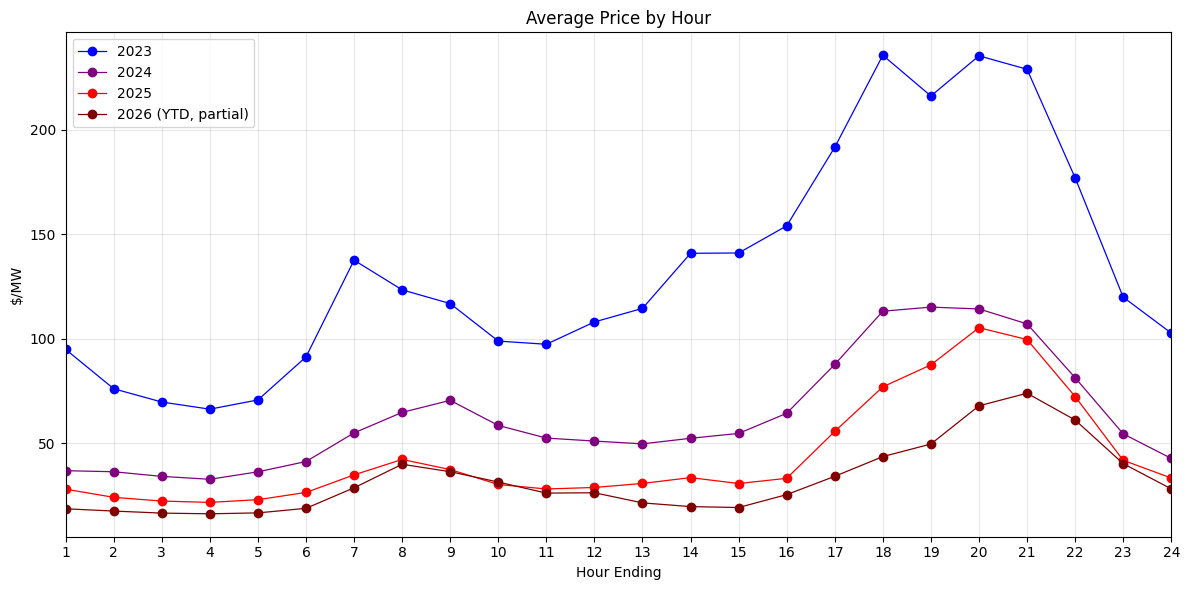

In [104]:
hourly_price_demand = ddb.sql('''
    select
        case when hour(date_he) = 0 then 24 else hour(date_he) end as hour,
        year(date_he) as year,
        avg(actual_ail) as avg_ail,
        avg(actual_price) as avg_price
    from ActualForecast
    group by year, hour
    order by year, hour
    ''').df()

price_pivot = hourly_price_demand.pivot(index='hour', columns='year', values='avg_price')

colors = ['blue', 'purple', 'red', 'maroon']

fig, ax = plt.subplots(figsize=(12, 6))
price_pivot.plot(ax=ax, alpha=1, color=colors, marker='o', linewidth=0.9)
ax.set_xlabel('Hour Ending')
ax.set_ylabel('$/MW')
ax.set_title('Average Price by Hour')
ax.set_xlim(1, 24)
ax.set_xticks(range(1, 25))
# Relabel the most recent year as partial
labels = [f'{int(y)} (YTD, partial)' if int(y) == 2026 else str(int(y))
          for y in price_pivot.columns]
ax.legend(labels, title=None, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Hourly prices dropped significantly from 2023 to 2024-2026. With Alberta's coal phase out completion in 2024, natural gas fired generators now predominantly set the marginal price making natural gas prices a key driver of electricity cost. This decline in the pool prices is explained by the drop of natural gas prices from 2023 as well as the addition of new gas fired and renewable generators capacity to the grid. https://discoverairdrie.com/articles/albertas-wholesale-power-price-dropped-53-in-2024-as-new-supply-surged

Prices hike during the morning ramp from 6 to 8 AM and again at the evening peak at 6 PM. Throughout the day, prices stabilize along a downward curve. Notably, prices remain elevated from 6 to 9 PM, despite demand declining during those hours.

#### Hourly price-demand relationship

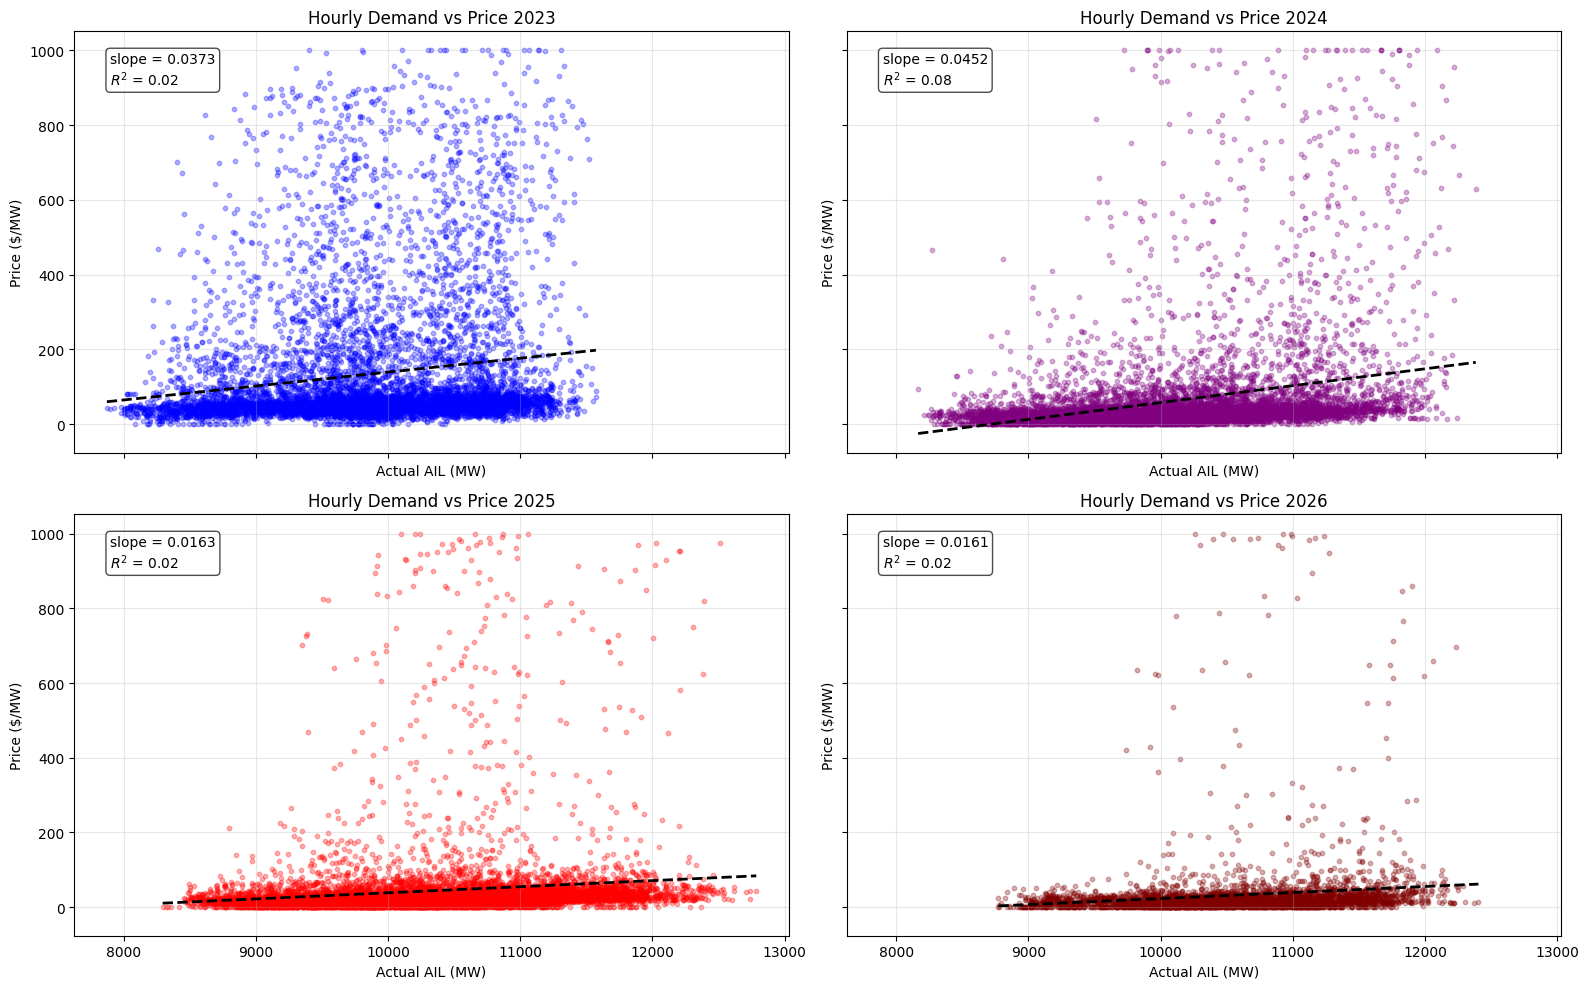

In [123]:
hourly_price_demand = ddb.sql('''
    select
        hour(date_he) as hour,
        dayofyear(date_he) as doy,
        year(date_he) as year,
        actual_price,
        actual_ail
    from ActualForecast
    order by year, doy, hour
    ''').df()

years = sorted(hourly_price_demand['year'].unique())
colors = ['blue', 'purple', 'red', 'maroon']

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, year, color in zip(axes, years, colors):
    grp = hourly_price_demand[hourly_price_demand['year'] == year]
    x, y = grp['actual_ail'].values, grp['actual_price'].values

    ax.scatter(x, y, color=color, alpha=0.3, s=10)

    # Line of best fit (kept in a contrasting color so it stays visible)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    xs = np.linspace(x.min(), x.max(), 100)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    ax.plot(xs, p(xs), 'k--', linewidth=2)

    ax.text(0.05, 0.95, f'slope = {z[0]:.4f}\n$R^2$ = {r2:.2f}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    ax.set_xlabel('Actual AIL (MW)')
    ax.set_ylabel('Price ($/MW)')
    ax.set_title(f'Hourly Demand vs Price {int(year)}')
    ax.grid(True, alpha=0.3)

for ax in axes[len(years):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

The price-demand scatter plots reveal a marginally positive relationship, though the near-flat slopes suggest almost no linear dependence between the two variables. The distribution of the observations is heavily concentrated at the lower price levels indicating that for most hours the market is generally well-behaved with some hours settling at the floor cap of $\text{ \$0/MWh} $, but with isolated hours, where prices drift from the norm even reaching the regulatory price cap of $ \text{ \$999.99/MWh } $.

This pattern is  expected given Alberta's merit order market structure, where generator bids are sorted from least to most expensive, dispatched sequentially until demand is met, and the marginal generator sets the price. As a result, prices depend on the available supply stack rather than demand. Extreme price events are more likely attributed to supply-side shocks such as unplanned outages, constrained generation capacity or congestion on the power line than to demand alone.

The continuous addition of renewable generators adds further complexity to Alberta's price formation. Since renewable generation carries near-zero marginal cost, these units are dispatched first in the merit order when available, displacing higher-cost natural gas generators and suppressing the pool price. This reinforces the earlier observation that higher demand does not always translate to higher prices when renewables are present on the grid — an hour of high renewable output coinciding with strong demand can yield lower prices, while an hour dominated by expensive marginal units under weak demand can produce elevated prices.